<a href="https://colab.research.google.com/github/cristiansvt/Sistemas-Avanzados-de-Produccion-9AN/blob/main/Notebooks/Semana6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

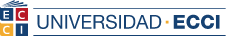
# **SISTEMAS AVANZADOS DE PRODUCCIÓN CON PYTHON**

# **De Regresión Lineal a Machine Learning**

**Objetivos de la sesión**

---

### **Clase 1: Cómo Arreglar y Mejorar tus Modelos 🛠️**

* **Detectar Problemas**: Aprender a identificar si el modelo memoriza demasiado (**sobreajuste**) o si es demasiado simple (**subajuste**).
* **Aplicar Soluciones**: Aprender a usar técnicas de regularización (**Ridge** y **Lasso**) para controlar la complejidad del modelo y mejorar su generalización.
* **Encontrar la Mejor Versión**: Aprender a utilizar una herramienta automática (**GridSearchCV**) para descubrir la configuración óptima de un modelo.

---







---

## **El Dilema del Ajuste: Sobreajuste y Subajuste 🎯**

- **Motivación / Pregunta Problema:**
    Imaginemos que nuestro objetivo es construir un modelo para un sistema de visión artificial que clasifica piezas en una línea de producción como **"Aptas"** o **"Defectuosas"**. Si creamos un modelo demasiado simple (ej. "si la pieza es oscura, es defectuosa"), fallará constantemente porque no puede capturar la complejidad real del problema. Por otro lado, si creamos un modelo extremadamente complejo, podría empezar a memorizar detalles irrelevantes de las fotos de entrenamiento, como una mancha de aceite en la cinta transportadora, y clasificar incorrectamente piezas futuras. **¿Cómo encontramos el balance perfecto entre un modelo que no aprende lo suficiente y uno que aprende demasiado?**

- **Contexto:**
    El objetivo central del machine learning no es crear un modelo que sea perfecto con los datos pasados, sino uno que **generalice** bien a datos futuros y desconocidos. En la búsqueda de este objetivo, nos enfrentamos a dos errores comunes:

    1.  **Subajuste (*Underfitting*):** Ocurre cuando el modelo es **demasiado simple** para capturar los patrones subyacentes en los datos. No logra un buen desempeño ni siquiera con los datos de entrenamiento. Es como un estudiante que no estudió lo suficiente y, por lo tanto, reprueba tanto los ejercicios de práctica como el examen final. **El modelo tiene un sesgo alto**.

    2.  **Sobreajuste (*Overfitting*):** Ocurre cuando el modelo es **demasiado complejo** y se ajusta no solo a los patrones de los datos, sino también al **ruido** y a las fluctuaciones aleatorias presentes en el set de entrenamiento. Este modelo obtiene un desempeño casi perfecto con los datos de entrenamiento, pero falla estrepitosamente con datos nuevos. Es como un estudiante que memorizó las respuestas exactas de la guía de estudio, pero es incapaz de resolver problemas ligeramente diferentes en el examen final. **El modelo tiene una varianza alta**.

<div align="center">
  <img src="https://www.mathworks.com/discovery/overfitting/_jcr_content/mainParsys/image.adapt.full.medium.svg/1746469504474.svg" width="80%">
</div>

---

## **¿Cómo se Identifican? Diagnóstico del Modelo**

La forma más directa de diagnosticar estos problemas es dividir nuestros datos en un conjunto de **entrenamiento** y un conjunto de **validación (o prueba)**, y comparar el desempeño del modelo en ambos.

- **Diagnóstico por Métricas:**
    - **Señal de Subajuste:** El error del modelo es **alto tanto en el conjunto de entrenamiento como en el de validación**. Las métricas son malas y muy similares en ambos conjuntos. El modelo simplemente no tiene la capacidad de aprender.
    - **Señal de Sobreajuste:** El error del modelo es **muy bajo en el conjunto de entrenamiento**, pero es **significativamente más alto en el conjunto de validación**. Esta "brecha" entre el desempeño en entrenamiento y validación es la señal de alerta clave del sobreajuste.

- **Diagnóstico Visual con Curvas de Aprendizaje:**
    Una curva de aprendizaje grafica el error del modelo en función de la cantidad de datos de entrenamiento. La interpretación de estas curvas es una herramienta de diagnóstico muy poderosa:
    - **Curva de Subajuste:** Las curvas de error de entrenamiento y validación convergen rápidamente en un **nivel de error alto**. Añadir más datos no ayuda, porque el problema es la simpleza del modelo.
    - **Curva de Sobreajuste:** La curva de error de entrenamiento se mantiene muy baja, mientras que la de validación se mantiene alta. Se observa una **brecha grande y persistente** entre ambas curvas.

<div align="center">
  <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/0*DeKaxBhcAOi_FGqQ.png" width="60%">
</div>

  Entender este dilema es el primer paso para construir modelos robustos. Técnicas como la **regularización** (Ridge y Lasso) son, en esencia, estrategias para combatir el sobreajuste y encontrar el punto óptimo.



-----

## **Preguntas cortas:**

<mark style="background-color: #FFF59D">**1.** Entrenas un modelo y obtienes un 99% de exactitud sobre los datos de entrenamiento, pero solo un 75% sobre los datos de prueba. ¿Qué problema indica este resultado y por qué?<mark>

<mark style="background-color: \#FFF59D">**2.** Si el error de tu modelo es muy alto tanto en el conjunto de entrenamiento como en el de validación, ¿cuál es el problema más probable? ¿Creerías que añadir más datos de entrenamiento solucionaría el problema?<mark>

Tamaños → Train: (700, 2) | Test: (300, 2)

=== Underfit / LogReg ===
Accuracy entrenamiento: 0.843
Accuracy validación   : 0.883

=== Balanced / SVM RBF ===
Accuracy entrenamiento: 0.911
Accuracy validación   : 0.927

=== Overfit / Árbol profundo ===
Accuracy entrenamiento: 1.000
Accuracy validación   : 0.900


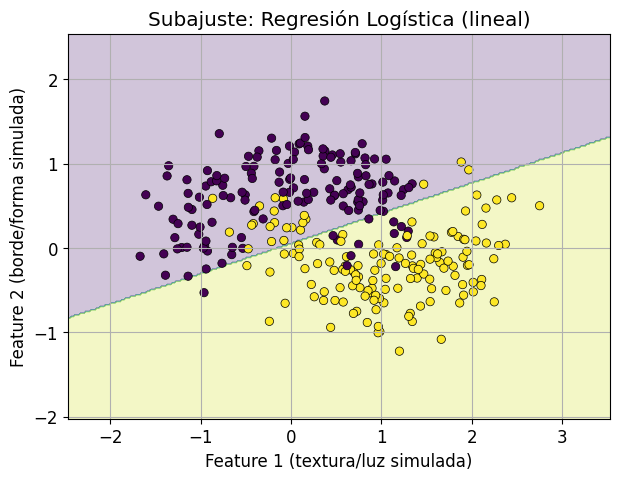

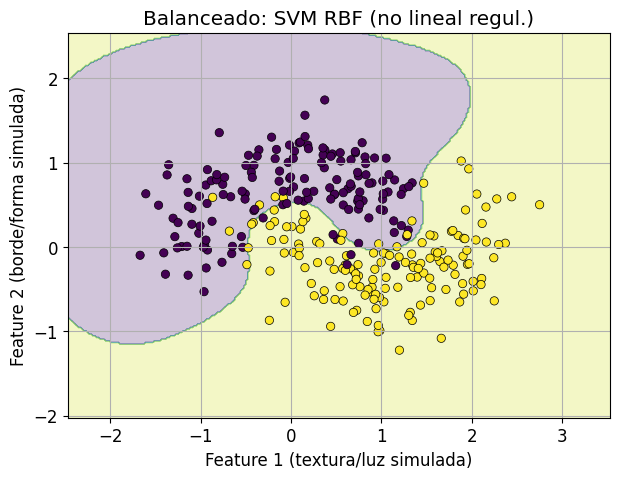

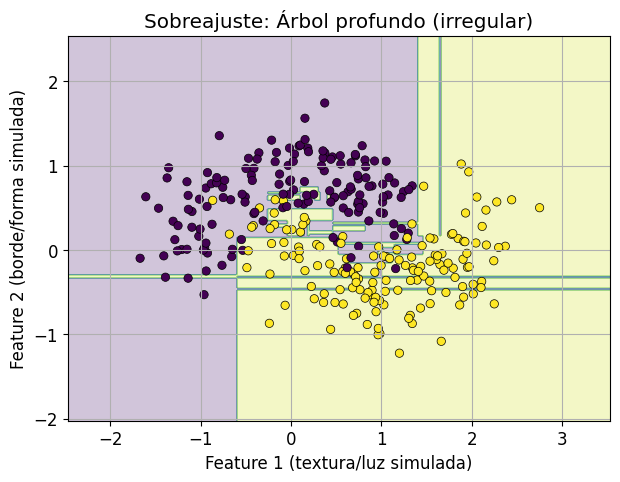

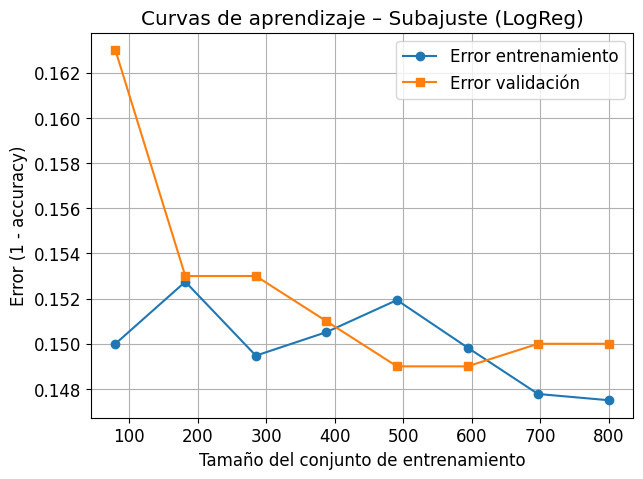

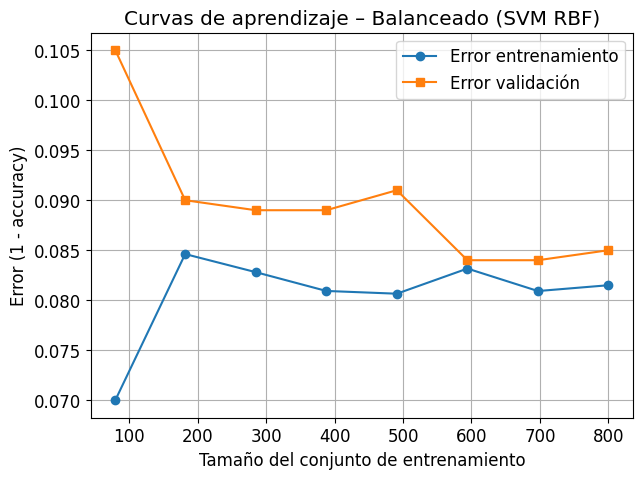

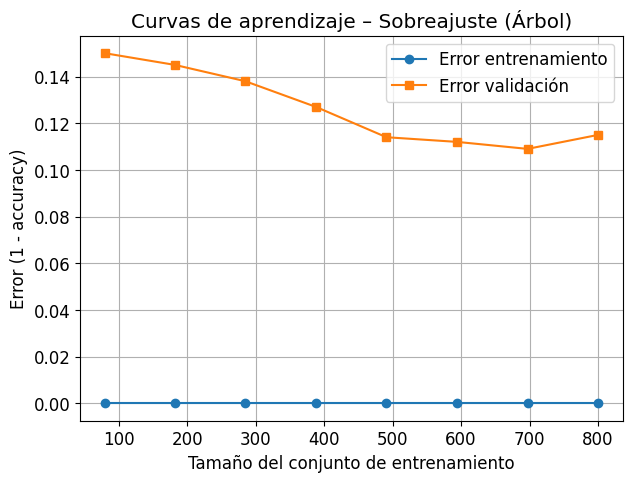

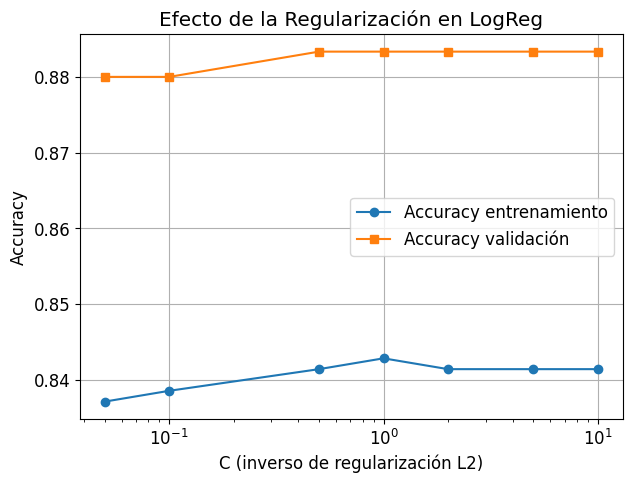


Matriz de confusión – Subajuste (LogReg)
              precision    recall  f1-score   support

           0      0.862     0.913     0.887       150
           1      0.908     0.853     0.880       150

    accuracy                          0.883       300
   macro avg      0.885     0.883     0.883       300
weighted avg      0.885     0.883     0.883       300



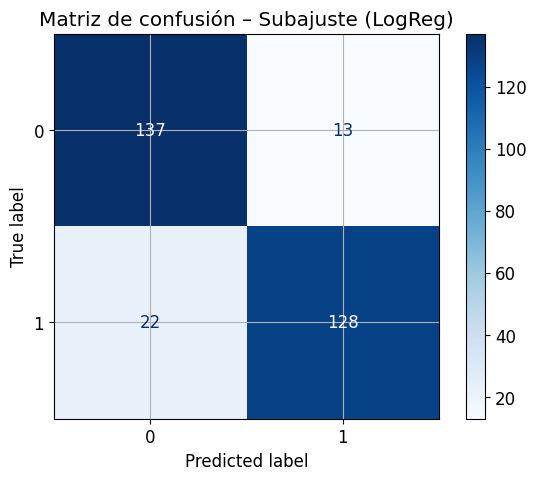


Matriz de confusión – Balanceado (SVM RBF)
              precision    recall  f1-score   support

           0      0.910     0.947     0.928       150
           1      0.944     0.907     0.925       150

    accuracy                          0.927       300
   macro avg      0.927     0.927     0.927       300
weighted avg      0.927     0.927     0.927       300



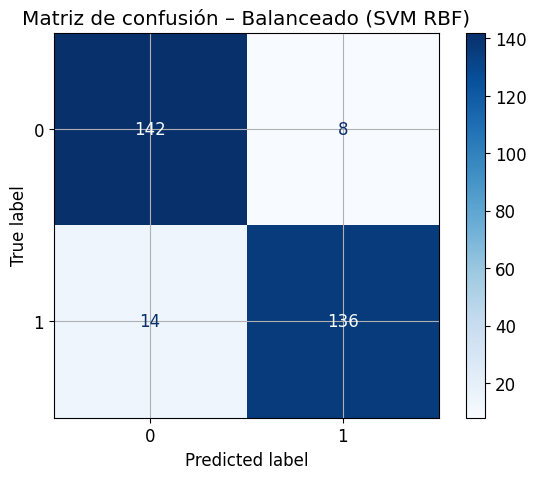


Matriz de confusión – Sobreajuste (Árbol)
              precision    recall  f1-score   support

           0      0.875     0.933     0.903       150
           1      0.929     0.867     0.897       150

    accuracy                          0.900       300
   macro avg      0.902     0.900     0.900       300
weighted avg      0.902     0.900     0.900       300



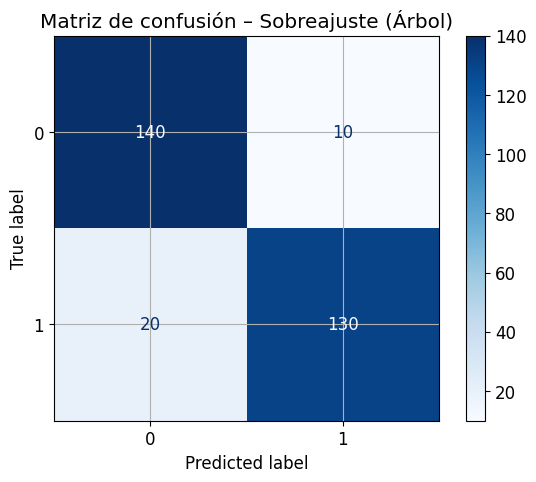


✅ Listo: ya tienes demostración visual + curvas de aprendizaje + regularización.


In [20]:
# -*- coding: utf-8 -*-
"""
El Dilema del Ajuste: Sobreajuste y Subajuste 🎯
Demostración visual con clasificación


(dataset tipo "visión artificial" simulado).
"""

# =========================
# 1) IMPORTS Y UTILIDADES
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "font.size": 12})

def plot_decision_boundary_2d(model, X, y, title="Frontera de decisión", step=0.02):
    # Solo para 2D (usamos las dos primeras características)
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', linewidths=0.5)
    plt.title(title)
    plt.xlabel("Feature 1 (textura/luz simulada)")
    plt.ylabel("Feature 2 (borde/forma simulada)")
    plt.show()

def plot_learning_curves(estimator, X, y, title="Curvas de aprendizaje", cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=None, shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, 1-train_mean, marker='o', label='Error entrenamiento')
    plt.plot(train_sizes, 1-val_mean, marker='s', label='Error validación')
    plt.title(title)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Error (1 - accuracy)")
    plt.legend()
    plt.show()

# =========================
# 2) DATOS: "VISIÓN" SIMULADA
# =========================
# make_moons: separación no lineal, análogo a texturas/contornos que no separa bien una recta.
X, y = make_moons(n_samples=1000, noise=0.30, random_state=42)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Tamaños → Train:", X_train.shape, "| Test:", X_test.shape)

# =========================
# 3) MODELOS DE DIFERENTE COMPLEJIDAD
# =========================
# 3.1) Subajuste (modelo muy simple): Regresión Logística (frontera lineal)
clf_under = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=1.0, max_iter=500, random_state=42))
])

# 3.2) Balanceado: SVM con kernel RBF (capta no linealidades con regularización)
clf_good = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=2.0, gamma=0.8, random_state=42))
])

# 3.3) Sobreajuste (muy complejo): Árbol profundo sin límite de profundidad
clf_over = DecisionTreeClassifier(max_depth=None, random_state=42)

# Entrenamos
for name, model in [("Underfit / LogReg", clf_under), ("Balanced / SVM RBF", clf_good), ("Overfit / Árbol profundo", clf_over)]:
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(f"Accuracy entrenamiento: {accuracy_score(y_train, y_tr):.3f}")
    print(f"Accuracy validación   : {accuracy_score(y_test, y_te):.3f}")

# =========================
# 4) FRONTERAS DE DECISIÓN
# =========================
plot_decision_boundary_2d(clf_under, X_test, y_test, title="Subajuste: Regresión Logística (lineal)")
plot_decision_boundary_2d(clf_good,  X_test, y_test, title="Balanceado: SVM RBF (no lineal regul.)")
plot_decision_boundary_2d(clf_over,  X_test, y_test, title="Sobreajuste: Árbol profundo (irregular)")

# =========================
# 5) CURVAS DE APRENDIZAJE (DIAGNÓSTICO)
# =========================
plot_learning_curves(clf_under, X, y, title="Curvas de aprendizaje – Subajuste (LogReg)")
plot_learning_curves(clf_good,  X, y, title="Curvas de aprendizaje – Balanceado (SVM RBF)")
plot_learning_curves(clf_over,  X, y, title="Curvas de aprendizaje – Sobreajuste (Árbol)")

# =========================
# 6) REGULARIZACIÓN: EFECTO DEL PARÁMETRO EN LOGREG
# =========================
# C es el inverso de la regularización L2 (Ridge): C ↑ -> menos regularización -> más riesgo de sobreajuste.
Cs = [0.05, 0.1, 0.5, 1, 2, 5, 10]
acc_tr_list, acc_te_list = [], []

for C in Cs:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=C, max_iter=500, random_state=42))
    ])
    model.fit(X_train, y_train)
    acc_tr_list.append(model.score(X_train, y_train))
    acc_te_list.append(model.score(X_test,  y_test))

plt.figure()
plt.plot(Cs, acc_tr_list, marker='o', label="Accuracy entrenamiento")
plt.plot(Cs, acc_te_list, marker='s', label="Accuracy validación")
plt.xscale('log')
plt.xlabel("C (inverso de regularización L2)")
plt.ylabel("Accuracy")
plt.title("Efecto de la Regularización en LogReg")
plt.legend()
plt.show()

# =========================
# 7) MATRICES DE CONFUSIÓN (UNA VISTA OPERATIVA)
# =========================
def plot_conf(model, Xtr, ytr, Xte, yte, title):
    from sklearn.metrics import ConfusionMatrixDisplay
    y_pred = model.predict(Xte)
    print("\n" + title)
    print(classification_report(yte, y_pred, digits=3))
    cm = confusion_matrix(yte, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.show()

plot_conf(clf_under, X_train, y_train, X_test, y_test, "Matriz de confusión – Subajuste (LogReg)")
plot_conf(clf_good,  X_train, y_train, X_test, y_test, "Matriz de confusión – Balanceado (SVM RBF)")
plot_conf(clf_over,  X_train, y_train, X_test, y_test, "Matriz de confusión – Sobreajuste (Árbol)")

print("\n✅ Listo: ya tienes demostración visual + curvas de aprendizaje + regularización.")


## **El Dilema del Modelo y la Regularización Ridge y Lasso 🛠️**

  - **Motivación / Pregunta Problema:**
    Imagine que se ha construido un modelo de regresión para predecir el consumo energético de una planta. Al entrenarlo con los datos históricos de un año, el modelo alcanza una exactitud del 99.9% sobre esos mismos datos. Sin embargo, al utilizarlo para predecir el consumo de la semana siguiente, su rendimiento es deficiente. **¿Cuál es la causa?** El modelo no ha aprendido las relaciones subyacentes del proceso; en su lugar, ha capturado el **ruido y las correlaciones espurias** de los datos de entrenamiento. Se ha vuelto un experto en describir el pasado, pero es incapaz de generalizar al futuro. Este fenómeno se conoce como **sobreajuste (*overfitting*)**.

  - **Contexto:**
    El sobreajuste ocurre cuando un modelo es excesivamente complejo para el conjunto de datos disponible. En la regresión lineal, esto a menudo se manifiesta en coeficientes (`β`) de gran magnitud, que fuerzan al modelo a ajustarse a variaciones menores en los datos. Para mitigar esto, es necesario restringir la complejidad del modelo. La **Regularización** es una familia de técnicas diseñadas precisamente para este fin, añadiendo una penalización a la función de costo del modelo.

-----

## **¿Cómo funciona la Regularización? La Técnica de Penalización**

  - El principio fundamental consiste en modificar el objetivo del entrenamiento. En lugar de buscar únicamente la minimización del error, se introduce una doble condición:

    1. Minimizar el error de predicción (Suma de Errores Cuadráticos).
    2. Mantener la magnitud de los coeficientes del modelo (`β`) bajo control.

  - Esta penalización sobre los coeficientes previene que el modelo asigne una importancia desmedida a predictores individuales. Las dos estrategias de regularización más importantes son Ridge y Lasso.

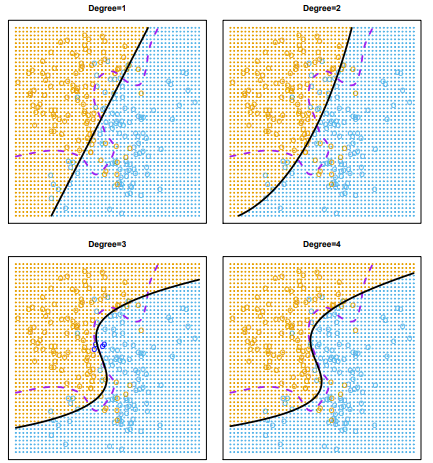

#### **Regularización Ridge (L2)**

  - La regresión Ridge añade una penalización equivalente a la suma de los **cuadrados** de los coeficientes. Este término (conocido como norma L2) reduce la magnitud de todos los coeficientes, acercándolos a cero sin que necesariamente lleguen a serlo. Es particularmente efectiva para crear modelos estables en presencia de multicolinealidad.

#### **Función de Costo Ridge:**
$$\text{Costo} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2$$

  - Donde el primer término es la suma de errores al cuadrado y el segundo es la **penalización L2**. El hiperparámetro `λ` (lambda) controla la intensidad de dicha penalización.

#### **Regularización Lasso (L1)**

  - La regresión Lasso impone una penalización equivalente a la suma de los **valores absolutos** de los coeficientes (norma L1). Una propiedad fundamental de esta penalización es su capacidad para reducir algunos coeficientes a **exactamente cero**. Por lo tanto, Lasso no solo regulariza el modelo, sino que también realiza una **selección de variables** implícita.



**Función de Costo Lasso:**
$$\text{Costo} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}|\beta_j|$$

  El segundo término es la **penalización L1**. Lasso es útil para identificar y descartar las variables menos relevantes del modelo.|


<div align="center">
  <img src="https://scientistcafe.com/ids/images/LassoRidge.png" width="80%">
</div>

  - **Interpretación visual:** Las elipses rojas son las curvas de nivel de la función de error, con el centro (`β̂`) representando la solución de mínimos cuadrados sin penalización. El área azul es la región de restricción impuesta por la regularización. La solución final se encuentra en el punto donde las elipses tocan por primera vez esta región.
      - La **restricción de Lasso (izquierda)**, con forma de rombo, tiene vértices sobre los ejes. Esto aumenta la probabilidad de que el punto de tangencia ocurra en un vértice, forzando a uno de los coeficientes a ser cero.
      - La **restricción de Ridge (derecha)**, de forma circular, no tiene vértices, por lo que el punto de contacto generalmente ocurre donde ambos coeficientes son distintos de cero.

-----

## **¿Por qué te importa en Ingeniería Industrial?**

  - **Ridge:** Se utiliza cuando se presume que la mayoría de las variables predictoras son relevantes y se busca estabilizar el modelo, especialmente si las variables están correlacionadas entre sí. Por ejemplo, al modelar la eficiencia de una línea con predictores como `velocidad_maquina`, `temperatura` y `humedad`.

  - **Lasso:** Es la elección preferida cuando se sospecha que muchas variables son redundantes o irrelevantes. Ayuda a simplificar el modelo y a mejorar su interpretabilidad. Por ejemplo, al predecir la calidad de un producto a partir de 50 lecturas de sensores, Lasso puede identificar los 5 predictores más influyentes y descartar el resto.

-----

## **Preguntas cortas:**

<mark style="background-color: #FFF59D">**1.** En un problema para predecir fallas en una máquina, tienes 100 variables provenientes de sensores, pero sospechas que solo unas pocas son realmente importantes. ¿Usarías Ridge o Lasso? Justifica tu respuesta.<mark>

<mark style="background-color: #FFF59D">**2.** Si entrenas un modelo Lasso y aumentas gradualmente el valor del hiperparámetro de penalización (λ), ¿qué efecto esperarías observar en los coeficientes del modelo?<mark>

<mark style="background-color: #FFF59D">**3.** Al ejecutar el código de regularización 3D, ¿qué sucede con los coeficientes del modelo a medida que aumenta el valor de λ? ¿Qué interpretación le das a la forma diferente en que Ridge y Lasso aplican sus penalizaciones?</mark>



## **Variables Categóricas y Dummies**

* **Motivación / pregunta problema:**
  ¿Cómo incorporar **turno**, **familia de producto**, **máquina**, **región** (no numéricos) al modelo sin perder interpretabilidad ni introducir sesgos?

* **Contexto:**
  Los modelos lineales requieren representaciones **numéricas**. Las **dummies** (One-Hot) permiten comparar categorías frente a una **categoría base**.

---

## ¿Qué son las dummies?

* Para una variable con $k$ categorías se crean $k-1$ columnas binarias (0/1) y se omite una **base** para evitar colinealidad perfecta.
* Coeficiente $\beta_{\text{cat}=j}$: diferencia esperada en $Y$ respecto a la **base**.


<div align="center">
  <img src="https://fhernanb.github.io/libro_regresion/images/embudo.png" width="50%">
</div>

---

## Ruta para codificar

1. **Elegir base** con sentido (p. ej., “sin promo”, “turno día”).
2. **One-Hot** en *train* (guardar columnas) y **aplicar igual** en *valid/test*.
3. **Cardinalidad alta**: agrupar *top-k* + “Otros”; considerar **target encoding** solo dentro de CV (controlando *leakage*).
4. **Unseen levels**: configurar codificador para ignorar/agrupar (evitar fallos en producción).
5. **Interacciones**: numérica×categoría (pendientes diferentes por grupo).

<div align="center">
  <img src="https://fhernanb.github.io/libro_regresion/images/var_cuali_01.png" width="70%">
</div>


---

## Alternativas y cuidado

* **Ordinal** si existe orden natural (p. ej., “Bajo\<Medio\<Alto”).
* **Effect coding** (contrastes suma cero) para comparar con la media global.
* Árboles/boosting toleran One-Hot; algunos frameworks aceptan categóricas nativas.

---

## Buenas prácticas

* Documentar **significado** de la base.
* Controlar **cardinalidad** (no crear miles de columnas).
* Tratar categorías raras (frecuencia baja) para robustez.
* Mantener todo en **Pipeline/ColumnTransformer**.

---

## Ejemplo: Velocidad de Máquina y Proveedor de Material

* **Objetivo**: Minimizar la tasa de defectos de una pieza metálica.

* **Variable Numérica**: Velocidad de la máquina (en RPM).

* **Variable Categórica**: Proveedor de la materia prima (Proveedor A vs. Proveedor B).

* Se encuentra una interacción significativa.

* **Interpretación Concreta**
  El análisis muestra que el efecto de la velocidad de la máquina sobre los defectos depende críticamente del proveedor.

* Con material del Proveedor A: Aumentar 100 RPM la velocidad no aumenta significativamente los defectos. El material es robusto.

* Con material del Proveedor B: Aumentar 100 RPM la velocidad dispara la tasa de defectos en un 5%. El material es sensible a la velocidad.

* Conclusión para el ingeniero:

  "No podemos simplemente aumentar la velocidad de la máquina para producir más. Si usamos el material del Proveedor B, estamos obligados a mantener una velocidad baja. Para operar a altas velocidades de forma rentable, es obligatorio usar el material del Proveedor A".

---

## ¿Por qué te importa en Ingeniería Industrial?

* **Turno** (día/noche) y **línea** afectan tiempos y calidad.
* **Familia de producto** segmenta demandas y mermas.
* **Región/cliente** explica patrones de consumo y devolución.

---

## Preguntas cortas:

<mark style="background-color: #FFF59D">1. Define una variable categórica de tu caso (o inventa una) y elige la **base**. Justifica.</mark>

<mark style="background-color: #FFF59D">2. Crea una **interacción** numérica×categoría y explica su interpretación.</mark>





In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# --- Cargar Boston Housing (Raschka) ---
url = ("https://raw.githubusercontent.com/rasbt/"
       "python-machine-learning-book-3rd-edition/"
       "master/ch10/housing.data.txt")
df = pd.read_csv(url, header=None, sep=r"\s+")
df.columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS",
              "RAD","TAX","PTRATIO","B","LSTAT","MEDV"]

# Objetivo (para mantener estructura, aunque hoy no modelamos)
y = df["MEDV"].copy()

# --- Elegimos algunas numéricas + 2 categóricas ---
# CHAS: 0/1 (categórica binaria)
# REGION: categórica creada al discretizar DIS (distancia a empleos) en 3 niveles
X = df[["RM","LSTAT","PTRATIO","DIS","CHAS"]].copy()

# Crear REGION por cuantiles (baja, media, alta distancia)
X["REGION"] = pd.qcut(X["DIS"], q=3, labels=["Cerca","Medio","Lejos"])
X = X.drop(columns=["DIS"])  # ya no usaremos la DIS numérica; quedamos con REGION categórica

num_cols = ["RM","LSTAT","PTRATIO"]     # numéricas
cat_cols = ["CHAS","REGION"]            # categóricas

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=123, shuffle=True
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=123, shuffle=True
)


# Pipeline numérico: imputación (mediana) + escalado (opcional para lineales)
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico: imputación de moda + One-Hot con base y niveles no vistos
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer que aplica cada pipeline a su tipo de columna
preprocess = ColumnTransformer(transformers=[
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


# Ajustar SOLO con train (evita leakage)
preprocess.fit(X_train)

# Transformar splits
Xtr_p = preprocess.transform(X_train)
Xva_p = preprocess.transform(X_valid)
Xte_p = preprocess.transform(X_test)

print("Formas:", Xtr_p.shape, Xva_p.shape, Xte_p.shape)

# Ver nombres de columnas resultantes (útil para interpretar la base)
num_names = num_cols
cat_names = preprocess.named_transformers_["cat"] \
                     .named_steps["onehot"] \
                     .get_feature_names_out(cat_cols).tolist()

all_names = num_names + cat_names
print("Columnas finales:")
for i, n in enumerate(all_names):
    print(f"{i:02d} -> {n}")


# Simular un level "nuevo" en valid:
X_valid_unk = X_valid.copy()
# Convert to object dtype temporarily to add new category
X_valid_unk["REGION"] = X_valid_unk["REGION"].astype("object")
X_valid_unk.loc[X_valid_unk.index[:5], "REGION"] = "MuyLejos"  # no vista en train


# Transformar (no debe fallar por handle_unknown='ignore')
_ = preprocess.transform(X_valid_unk)
print("OK: categorías nuevas no rompen gracias a handle_unknown='ignore'.")


def add_interactions(X_arr: np.ndarray) -> np.ndarray:
    """
    X_arr es la matriz ya preprocesada (num escaladas + dummies).
    Vamos a multiplicar la 1ª numérica (RM escalada) por cada dummy de REGION
    solo como ejemplo didáctico.
    """
    # Recuperar índices: num primero, luego cat
    n_num = len(num_cols)
    mat = X_arr.copy()

    # Columnas numéricas escaladas:
    RM_scaled = mat[:, 0:1]  # asumimos RM es la primera en num_cols

    # Columnas categóricas (todas las dummies, CHAS y REGION)
    cat_block = mat[:, n_num:]

    # Elegimos solo las dummies de REGION (últimas 2 en este ejemplo)
    # Nota: si cambias el orden, ajusta estos índices.
    REG_dummies = cat_block[:, -2:]  # [REGION_Medio, REGION_Lejos] (base=Cerca)

    # Interacciones RM×REGION_*  → dos nuevas columnas
    interactions = RM_scaled * REG_dummies

    # Concatenamos al final
    return np.hstack([mat, interactions])

# Pipeline completo: preprocess + FunctionTransformer para interacciones
from sklearn.preprocessing import FunctionTransformer
pipe_with_inter = Pipeline([
    ("prep", preprocess),
    ("inter", FunctionTransformer(add_interactions, validate=False))
])

pipe_with_inter.fit(X_train)
Xt = pipe_with_inter.transform(X_train)
print("Con interacciones, forma:", Xt.shape)

# Nombres extendidos (a mano para explicar):
ext_names = all_names + ["RMxREGION_Medio","RMxREGION_Lejos"]
print("Nuevas columnas:", ext_names[-2:])


Formas: (354, 6) (76, 6) (76, 6)
Columnas finales:
00 -> RM
01 -> LSTAT
02 -> PTRATIO
03 -> CHAS_1
04 -> REGION_Lejos
05 -> REGION_Medio
OK: categorías nuevas no rompen gracias a handle_unknown='ignore'.
Con interacciones, forma: (354, 8)
Nuevas columnas: ['RMxREGION_Medio', 'RMxREGION_Lejos']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros





## **Minimización de la Función de Costo con Gradient Descent**

* **Motivación / pregunta problema:**
  Cuando la solución cerrada no es práctica (datos grandes, modelos complejos) o buscas entrenamiento **iterativo**, ¿cómo optimizar **rápido y estable**?

* **Contexto:**
  **Gradient Descent (GD)** minimiza una función de costo moviéndose en la dirección **opuesta** al gradiente. Es la base de la optimización en **regresión**, **logística** y **redes**.

---

## ¿Qué es (para MSE)?

* Costo (lineal):

  $$
  J(\boldsymbol\theta)=\frac{1}{2n}\sum_{i=1}^{n}\big(\hat{y}_i-y_i\big)^2,\quad
  \nabla J=\frac{1}{n}\mathbf{X}^\top(\mathbf{X}\boldsymbol\theta-\mathbf{y})
  $$
* **Actualización**:

  $$
  \boldsymbol\theta\leftarrow \boldsymbol\theta-\alpha\,\nabla J
  $$

  con **tasa de aprendizaje** $\alpha>0$.

---

## Sabores de GD

* **Batch GD**: usa todo el conjunto (estable, pero costoso).
* **SGD**: un ejemplo por paso (ruidoso, rápido, permite *online*).
* **Mini-batch**: compromiso práctico (más usado).

---

## Ruta para aplicar

1. **Escalar/normalizar** variables (mejora la curvatura).
2. Elegir **$\alpha$** (grid o *schedules*: *time decay*, *cosine*).
3. Elegir **tamaño de batch** (32–512 típico).
4. **Optimizador**: GD/SGD con **Momentum**, **Nesterov**, **Adagrad**, **RMSProp**, **Adam**.
5. **Criterio de paro**: pérdida en *valid*, gradiente pequeño, o **early stopping**.
6. **Curvas de entrenamiento**: vigilar **overfitting** (divergencia train vs valid).

---

## Convexidad y regularización

* Para **regresión lineal con MSE**, $J$ es **convexa** ⇒ mínimo global.
* Añadir **L2 (ridge)** o **L1 (lasso)**:

  $$
  J_{\text{ridge}}=J+\lambda\|\boldsymbol\theta\|_2^2,\qquad
  J_{\text{lasso}}=J+\lambda\|\boldsymbol\theta\|_1
  $$

  Controla sobreajuste y mejora condición numérica.

---

## Buenas prácticas

* **Barajar** datos entre épocas (SGD/mini-batch).
* Registrar pérdida **train/valid**; usar **early stopping**.
* **Semilla** reproducible; *learning-rate warmup* si es grande.
* Evitar $\alpha$ alta (diverge) o demasiado baja (converge lento).

---

## Errores frecuentes

* No escalar datos → oscilaciones o lentitud.
* Medir solo pérdida de **train**.
* No controlar **regularización**; olvidar **weight decay** en redes.
* Hacer *grid* de $\alpha$ usando **test** (fuga).

---

## ¿Por qué te importa en Ingeniería Industrial?

* **Datos masivos** de sensores/SCADA → mini-batch/SGD.
* **Aprendizaje continuo** en línea (drift de proceso).
* **Restricciones de cómputo** en planta → optimizadores eficientes.

---


In [22]:
 #Plotly: superficie de Himmelblau con colores que resaltan mínimos + marcadores
import numpy as np
import plotly.graph_objects as go

def f(x,y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Malla
x = np.linspace(-6,6,300); y = np.linspace(-6,6,300)
X, Y = np.meshgrid(x,y); Z = f(X,Y)

# Color: enfatizar mínimos (mapear color a Z**gamma, gamma<1)
gamma = 0.35
C = Z**gamma

# Escala de color: viridis invertida (bajo = amarillo claro)
colorscale = 'Viridis'
reversescale = True

# Rango del color comprimido para ver mejor el fondo (mínimos)
cmin = float(C.min())
cmax = float(np.percentile(C, 95))  # evita que los picos saturen

fig = go.Figure()

fig.add_trace(go.Surface(
    x=X, y=Y, z=Z, surfacecolor=C,
    colorscale=colorscale, reversescale=reversescale,
    cmin=cmin, cmax=cmax,
    colorbar=dict(title="f(x,y)", len=0.7),
    contours=dict(
        z=dict(show=True, start=0, end=float(np.percentile(Z, 85)), size=10)
    )
))

# Mínimos globales conocidos
mins = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126],
])
Zmins = f(mins[:,0], mins[:,1])

fig.add_trace(go.Scatter3d(
    x=mins[:,0], y=mins[:,1], z=Zmins,
    mode='markers+text',
    text=[f"({mx:.3g},{my:.3g})" for mx,my in mins],
    textposition="top center",
    marker=dict(size=5, color='red', symbol='circle'),
    name='Mínimos'
))

fig.update_layout(
    title="Himmelblau — Mínimos resaltados (bajo = claro)",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="f(x,y)",
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0))
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()




In [25]:
# -*- coding: utf-8 -*-
# Paso 1: Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Paso 2: Definir la función y su gradiente
# Esta función tiene múltiples mínimos locales para que el algoritmo pueda "atascarse"
def f(x, y):
    """Función de superficie con dos mínimos locales."""
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def grad_f(x, y):
    """Gradiente (derivadas parciales) de la función f."""
    df_dx = 2 * (x**2 + y - 11) * (2*x) + 2 * (x + y**2 - 7)
    df_dy = 2 * (x**2 + y - 11) + 2 * (x + y**2 - 7) * (2*y)
    return np.array([df_dx, df_dy])

# Paso 3: Implementar el algoritmo de Descenso del Gradiente
def gradient_descent(start_pos, learning_rate, num_iterations):
    """
    Ejecuta el descenso del gradiente y guarda la trayectoria.

    Args:
        start_pos (np.array): Punto de inicio [x, y].
        learning_rate (float): Tasa de aprendizaje (tamaño del paso).
        num_iterations (int): Número de pasos a realizar.

    Returns:
        np.array: Un array con la trayectoria de los puntos (x, y, z).
    """
    path = []
    point = np.array(start_pos, dtype=float)

    for i in range(num_iterations):
        z = f(point[0], point[1])
        path.append([point[0], point[1], z])

        # Calcula el gradiente
        grad = grad_f(point[0], point[1])

        # Actualiza la posición del punto
        point = point - learning_rate * grad

    return np.array(path)

# --- CONFIGURACIÓN DE LA SIMULACIÓN ---
# Punto de inicio (puedes cambiarlo para ver cómo cae en otro mínimo)
start_point = [6.0, -6.0]
learning_rate = 0.0001      # Tasa de aprendizaje
num_iterations = 1000       # Número de pasos

# Ejecutar el algoritmo
path = gradient_descent(start_point, learning_rate, num_iterations)

# --- PREPARACIÓN DE LA VISUALIZACIÓN ---
# Crear la malla de puntos para la superficie 3D y las curvas de nivel
x = np.linspace(-7, 7, 200)
y = np.linspace(-7, 7, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Crear la figura y los dos subplots (3D y 2D)
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2)

# --- DIBUJO DE LA SUPERFICIE Y LAS CURVAS DE NIVEL ---

# Subplot 1: Superficie 3D
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, rstride=10, cstride=10, edgecolor='none')
ax1.set_title('Descenso del Gradiente en 3D', fontsize=16)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x, y)')
ax1.view_init(elev=50, azim=-70) # Ajustar el ángulo de la vista 3D

# Subplot 2: Proyección en curvas de nivel
contour = ax2.contour(X, Y, Z, levels=np.logspace(0, 5, 35), cmap='viridis', alpha=0.8)
fig.colorbar(contour, ax=ax2, label='Valor de f(x,y)')
ax2.set_title('Proyección en Curvas de Nivel', fontsize=16)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal', adjustable='box')

# Elementos que se animarán
line_3d, = ax1.plot([], [], [], 'r-o', markersize=4, lw=2, label='Trayectoria')
point_3d, = ax1.plot([], [], [], 'go', markersize=8, label='Punto Actual')
line_2d, = ax2.plot([], [], 'r-o', markersize=4, lw=2)
point_2d, = ax2.plot([], [], 'go', markersize=8)

ax1.legend()

# --- FUNCIÓN DE ANIMACIÓN ---
def update(frame):
    # Actualiza los datos de las líneas y puntos hasta el frame actual
    line_3d.set_data(path[:frame, 0], path[:frame, 1])
    line_3d.set_3d_properties(path[:frame, 2])
    point_3d.set_data(path[frame:frame+1, 0], path[frame:frame+1, 1])
    point_3d.set_3d_properties(path[frame:frame+1, 2])

    line_2d.set_data(path[:frame, 0], path[:frame, 1])
    point_2d.set_data(path[frame:frame+1, 0], path[frame:frame+1, 1])

    return line_3d, point_3d, line_2d, point_2d

# Crear y mostrar la animación
ani = FuncAnimation(fig, update, frames=len(path), blit=True, interval=20)

# Convertir la animación a un formato compatible con Colab (HTML5)
plt.close(fig) # Evita que se muestre una figura estática extra
HTML(ani.to_html5_video())